<a href="https://colab.research.google.com/github/Janmeshree/ML-PRACS/blob/main/ML_SINGLE_PERCEPTRON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [2]:
data = load_iris()

# take only 2 features and 2 classes
X = data.data[:, :2]
y = data.target

# take only class 0 and 1 (linearly separable)
mask = y != 2
X = X[mask]
y = y[mask]

# convert to -1 and 1
y = np.where(y == 0, -1, 1)

df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["Target"] = y

df.head()

,Feature1,Feature2,Target
0,5.1,3.5,-1
1,4.9,3.0,-1
2,4.7,3.2,-1
3,4.6,3.1,-1
4,5.0,3.6,-1


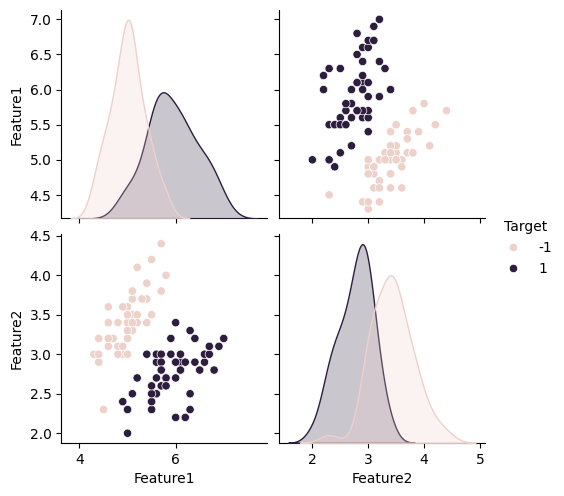

In [4]:
import seaborn as sns

sns.pairplot(df, hue='Target', diag_kind='kde')
plt.show()

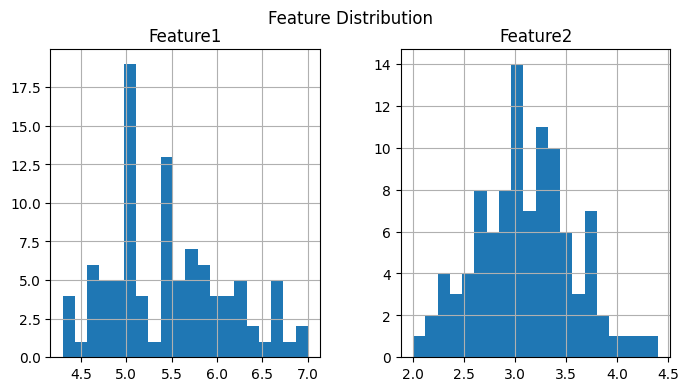

In [5]:
df[['Feature1','Feature2']].hist(figsize=(8,4), bins=20)
plt.suptitle("Feature Distribution")
plt.show()

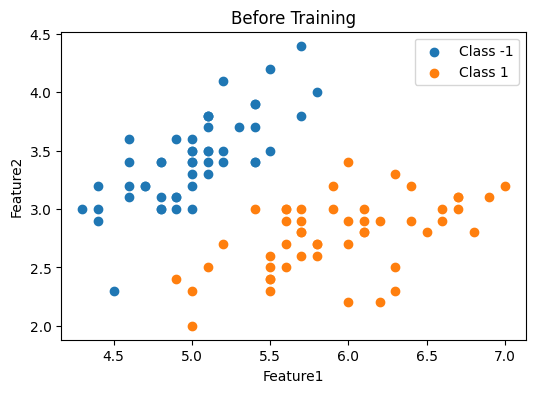

In [3]:
plt.figure(figsize=(6,4))
for label in np.unique(y):
    plt.scatter(df[df['Target']==label]['Feature1'],
                df[df['Target']==label]['Feature2'],
                label=f'Class {label}')

plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Before Training")
plt.legend()
plt.show()

In [11]:
np.random.seed(42)

learning_rate = 0.01
epochs = 50

weights = np.random.uniform(-0.5, 0.5, size=X.shape[1])
bias = np.random.uniform(-0.5, 0.5)

print("Initial Weights:", weights)
print("Initial Bias:", bias)

Initial Weights: [-0.12545988  0.45071431]
Initial Bias: 0.2319939418114051


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [13]:
def activation(x):
    return np.where(x >= 0, 1, -1)

errors = []

for epoch in range(epochs):
    error_count = 0
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_pred = activation(linear_output)

        update = learning_rate * (y[i] - y_pred)
        weights += update * X[i]
        bias += update

        if update != 0:
            error_count += 1

    errors.append(error_count)

print("Trained Weights:", weights)
print("Trained Bias:", bias)

Trained Weights: [ 0.09947997 -0.07458367]
Trained Bias: 0.011993941811405121


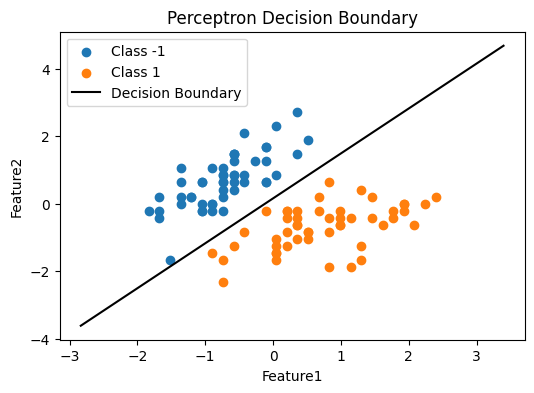

In [15]:
plt.figure(figsize=(6,4))

for label in np.unique(y):
    plt.scatter(X[y==label][:,0], X[y==label][:,1],
                label=f'Class {label}')

x1 = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)

if weights[1] != 0:
    x2 = -(weights[0]*x1 + bias)/weights[1]
    plt.plot(x1, x2, color='black', label='Decision Boundary')

plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Perceptron Decision Boundary")
plt.legend()
plt.show()